<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/tonal_aeroacoustic_root_cause_gate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tonal valve and piping noise: an evidence-gated PEPR workflow with NeqSim

This notebook turns a reported **500–1000 Hz tonal noise and vibration case** into a
reproducible Production Engineering Peer Review (PEPR) workflow. A pressure reduction
reduced the observed response. That is evidence that acoustic energy depends on the
operating state; it does **not** identify which component generated or amplified the tone.

The notebook therefore separates four questions:

1. What thermodynamic state and pressure-drop energy does NeqSim predict?
2. What can valve-noise, AIV, FIV, and side-branch screens legitimately say?
3. What evidence is required to distinguish an aerodynamic tone from an acoustic,
   structural, support, or machine resonance?
4. When must the agent stop instead of declaring a root cause?

**Learning outcomes**

- build a synthetic dry-gas letdown case and retain SI-unit thermodynamic evidence;
- use current NeqSim screening classes without treating them as source locators;
- demonstrate why steady RANS is useful for mean velocity and wall shear but cannot
  identify a narrow-band tonal source;
- run a time-marching one-dimensional compressible finite-volume CFD/CAA verification
  and recover its imposed tone from virtual pressure sensors;
- derive sampling, time-step, wavelength, geometry, and modal-data requirements;
- route the investigation to transient compressible aeroacoustics and structural
  dynamics when the evidence demands it;
- produce a PEPR conclusion that remains unresolved when causal gates are not met.

## Public case boundary

The case below is a **synthetic, non-identifying teaching proxy**. It preserves only the
mechanism pattern supplied for this exercise:

- a tone was reported somewhere inside 500–1000 Hz;
- noise or vibration decreased after a pressure reduction;
- a pressure-reducing valve, a side branch or check device, structural/support modes,
  machine excitation, and main-line flow-induced vibration remain competing hypotheses;
- real spectra, synchronized operating trends, actual valve internals, as-built branch
  geometry, and modal data have not been supplied to this public notebook.

No asset name, equipment tag, controlled-document identifier, or proprietary process value
is used. Every numerical input below is visibly labelled **synthetic**. Replace it only in a
governed project copy, not in the public notebook.

## Method boundary: screening is not causality

IEC 60534-8-3 provides a theoretical control-valve aerodynamic-noise prediction method for
single-phase dry gases and vapours. It can estimate sound level and frequency content for a
specified valve and adjacent piping, but it cannot localize an installed field source without
the real inputs and corroborating measurements.

A steady RANS solution represents a statistically steady mean flow. It may qualify local mean
velocity, pressure loss, recirculation, and wall shear. A tonal source is an unsteady pressure
field. The aeroacoustic route therefore requires a transient compressible calculation with
validated time and spatial resolution, followed by near- or far-field acoustic evaluation.
NASA's computational-aeroacoustics overview likewise describes acoustic analogies as requiring
unsteady flow input.

Structural resonance is a separate hypothesis. It requires natural frequencies, damping, and
mode shapes from an as-built model or modal/operational-deflection measurement. Frequency
coincidence alone is not causality.

Primary and authoritative references:

- [IEC 60534-8-3:2010 — control-valve aerodynamic noise](https://webstore.iec.ch/en/publication/2474)
- [Energy Institute — vibration-induced fatigue guidance](https://www.energyinst.org/industry/publications/topics/asset-integrity/guidelines-for-the-avoidance-of-vibration-induced-fatigue-failure-in-process-pipework)
- [OpenFOAM `rhoPimpleFoam` — transient compressible solver](https://doc.openfoam.com/2306/tools/processing/solvers/rtm/compressible/rhoPimpleFoam/)
- [NASA — overview of computational aeroacoustic modelling](https://ntrs.nasa.gov/api/citations/20020050415/downloads/20020050415.pdf)
- [NASA — modern modal testing cautions](https://ntrs.nasa.gov/api/citations/20190001554/downloads/20190001554.pdf)

## 1. Install the released NeqSim package

The public notebook uses the newest released PyPI package available in a clean Colab runtime.
The executed output records the actual version. No unpublished JAR or private dependency is
required.

In [1]:
!pip install neqsim

In [2]:
import importlib.metadata
import json
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim


NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda value: f"{value:,.5g}")

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")

NeqSim version: 3.18.0
Python version: 3.12.13


## 2. Governed facts and missing evidence

The first PEPR action is to encode what is known without silently converting a statement into
a measurement. A reported band is not a stored spectrum, and a qualitative intervention
response is not a transfer function.

In [3]:
case_evidence = pd.DataFrame(
    [
        {
            "item": "Reported tonal band",
            "status": "available as a statement",
            "value": "500–1000 Hz",
            "causal use": "Defines the search band only",
        },
        {
            "item": "Response after pressure reduction",
            "status": "available qualitatively",
            "value": "decreased",
            "causal use": "Supports operating-state dependence, not source location",
        },
        {
            "item": "Synchronized pressure, flow, position, and speed",
            "status": "missing",
            "value": "—",
            "causal use": "Required for order and Strouhal tracking",
        },
        {
            "item": "Time-domain sound and vibration",
            "status": "missing",
            "value": "—",
            "causal use": "Required for spectra, phase, coherence, and localization",
        },
        {
            "item": "Actual valve and adjacent piping geometry",
            "status": "missing",
            "value": "—",
            "causal use": "Required for valve noise, CFD, and acoustic modes",
        },
        {
            "item": "Structural modal data",
            "status": "missing",
            "value": "—",
            "causal use": "Required to test structural/support resonance",
        },
    ]
)

case_evidence

,item,status,value,causal use
0,Reported tonal band,available as a statement,500–1000 Hz,Defines the search band only
1,Response after pressure reduction,available qualitatively,decreased,"Supports operating-state dependence, not source location"
2,"Synchronized pressure, flow, position, and speed",missing,—,Required for order and Strouhal tracking
3,Time-domain sound and vibration,missing,—,"Required for spectra, phase, coherence, and localization"
4,Actual valve and adjacent piping geometry,missing,—,"Required for valve noise, CFD, and acoustic modes"
5,Structural modal data,missing,—,Required to test structural/support resonance


## 3. Synthetic NeqSim gas and isenthalpic letdown

The synthetic proxy uses an SRK equation of state with the classic mixing rule. Composition is
on a mole basis and sums to one. Pressure is absolute. Mass flow is actual mass flow.

The downstream state is calculated at constant total enthalpy:

$$h_2=h_1$$

The local bulk velocity used in later screens is

$$U=\frac{\dot{m}}{\rho A},\qquad A=\frac{\pi D^2}{4}$$

These are boundary-condition calculations. They do not identify an acoustic source.

In [4]:
TEMPERATURE_K = 318.15
UPSTREAM_PRESSURE_BARA = 55.0
DOWNSTREAM_PRESSURE_BARA = 15.0
MASS_FLOW_KG_PER_S = 25.0
PIPE_INTERNAL_DIAMETER_M = 0.254
PIPE_WALL_THICKNESS_M = 0.0127
PIPE_OUTSIDE_DIAMETER_M = (
    PIPE_INTERNAL_DIAMETER_M + 2.0 * PIPE_WALL_THICKNESS_M
)

synthetic_composition = {
    "nitrogen": 0.02,
    "CO2": 0.02,
    "methane": 0.88,
    "ethane": 0.06,
    "propane": 0.02,
}

assert np.isclose(sum(synthetic_composition.values()), 1.0, atol=1.0e-12)

upstream_fluid = jneqsim.thermo.system.SystemSrkEos(
    TEMPERATURE_K,
    UPSTREAM_PRESSURE_BARA,
)

for component_name, mole_fraction in synthetic_composition.items():
    upstream_fluid.addComponent(component_name, mole_fraction)

upstream_fluid.setMixingRule("classic")
upstream_fluid.setTotalFlowRate(MASS_FLOW_KG_PER_S, "kg/sec")

upstream_operations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations(upstream_fluid)
)
upstream_operations.TPflash()
upstream_fluid.initProperties()
upstream_fluid.initPhysicalProperties()

downstream_fluid = upstream_fluid.clone()
downstream_fluid.setPressure(DOWNSTREAM_PRESSURE_BARA, "bara")
downstream_operations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations(downstream_fluid)
)
downstream_operations.PHflash(upstream_fluid.getEnthalpy())
downstream_fluid.initProperties()
downstream_fluid.initPhysicalProperties()

upstream_phase = upstream_fluid.getPhase(0)
downstream_phase = downstream_fluid.getPhase(0)

assert upstream_fluid.getNumberOfPhases() == 1
assert downstream_fluid.getNumberOfPhases() == 1
assert str(upstream_phase.getPhaseTypeName()) == "gas"
assert str(downstream_phase.getPhaseTypeName()) == "gas"

upstream_density_kg_per_m3 = upstream_phase.getDensity("kg/m3")
downstream_density_kg_per_m3 = downstream_phase.getDensity("kg/m3")
upstream_sound_speed_m_per_s = upstream_phase.getSoundSpeed()
downstream_sound_speed_m_per_s = downstream_phase.getSoundSpeed()
downstream_viscosity_pa_s = downstream_phase.getViscosity("kg/msec")
molecular_weight_g_per_mol = 1_000.0 * upstream_phase.getMolarMass()
isentropic_exponent = (
    downstream_phase.getCp("J/kgK") / downstream_phase.getCv("J/kgK")
)

pipe_area_m2 = math.pi * PIPE_INTERNAL_DIAMETER_M**2 / 4.0
bulk_velocity_m_per_s = (
    MASS_FLOW_KG_PER_S / downstream_density_kg_per_m3 / pipe_area_m2
)
bulk_mach_number = bulk_velocity_m_per_s / downstream_sound_speed_m_per_s
bulk_reynolds_number = (
    downstream_density_kg_per_m3
    * bulk_velocity_m_per_s
    * PIPE_INTERNAL_DIAMETER_M
    / downstream_viscosity_pa_s
)

state_table = pd.DataFrame(
    {
        "quantity": [
            "temperature",
            "pressure",
            "density",
            "speed of sound",
            "molecular weight",
        ],
        "unit": ["K", "bara abs", "kg/m3", "m/s", "g/mol"],
        "upstream": [
            upstream_fluid.getTemperature("K"),
            upstream_fluid.getPressure("bara"),
            upstream_density_kg_per_m3,
            upstream_sound_speed_m_per_s,
            molecular_weight_g_per_mol,
        ],
        "downstream": [
            downstream_fluid.getTemperature("K"),
            downstream_fluid.getPressure("bara"),
            downstream_density_kg_per_m3,
            downstream_sound_speed_m_per_s,
            1_000.0 * downstream_phase.getMolarMass(),
        ],
    }
)

state_table

,quantity,unit,upstream,downstream
0,temperature,K,318.15,300.38
1,pressure,bara abs,55,15
2,density,kg/m3,41.36,11.304
3,speed of sound,m/s,423.48,414.49
4,molecular weight,g/mol,18.244,18.244


In [5]:
hydraulic_summary = pd.Series(
    {
        "synthetic mass flow [kg/s]": MASS_FLOW_KG_PER_S,
        "pipe internal diameter [m]": PIPE_INTERNAL_DIAMETER_M,
        "downstream bulk velocity [m/s]": bulk_velocity_m_per_s,
        "downstream Mach number [-]": bulk_mach_number,
        "downstream Reynolds number [-]": bulk_reynolds_number,
        "isentropic exponent [-]": isentropic_exponent,
    },
    name="Synthetic hydraulic boundary",
)

assert bulk_velocity_m_per_s > 0.0
assert bulk_mach_number < 1.0
assert bulk_reynolds_number > 4_000.0

hydraulic_summary

synthetic mass flow [kg/s]               25
pipe internal diameter [m]            0.254
downstream bulk velocity [m/s]       43.645
downstream Mach number [-]           0.1053
downstream Reynolds number [-]   1.0748e+07
isentropic exponent [-]              1.3336
Name: Synthetic hydraulic boundary, dtype: float64

## 4. Valve-noise and acoustic-induced-vibration screens

The NeqSim valve-noise calculation estimates stream power, flow regime, transmission loss,
outlet Mach number, and an external A-weighted sound-pressure level for a specified synthetic
valve. The AIV calculation screens pressure-drop acoustic power against a pipe geometry line.

The assumed valve outlet diameter, $F_L$, $F_d$, and pipe dimensions below are deliberately
synthetic. Their outputs answer **"could this service be acoustically energetic?"**, not
**"did this installed valve generate the reported tone?"** The second question remains blocked
until actual geometry and synchronized spectra exist.

In [6]:
VALVE_OUTLET_DIAMETER_M = 0.18
VALVE_PRESSURE_RECOVERY_FACTOR = 0.90
VALVE_STYLE_MODIFIER = 0.40

ValveNoise = (
    jneqsim.process.mechanicaldesign.valve.ControlValveNoise_IEC_60534_8_3
)
valve_noise = ValveNoise()
valve_noise.setFlowConditions(
    MASS_FLOW_KG_PER_S,
    UPSTREAM_PRESSURE_BARA * 1.0e5,
    DOWNSTREAM_PRESSURE_BARA * 1.0e5,
    upstream_density_kg_per_m3,
    downstream_density_kg_per_m3,
)
valve_noise.setAcousticProperties(
    upstream_sound_speed_m_per_s,
    downstream_sound_speed_m_per_s,
    isentropic_exponent,
)
valve_noise.setGeometry(
    VALVE_OUTLET_DIAMETER_M,
    PIPE_INTERNAL_DIAMETER_M,
    PIPE_WALL_THICKNESS_M,
)
valve_noise.setValveCoefficients(
    VALVE_PRESSURE_RECOVERY_FACTOR,
    VALVE_STYLE_MODIFIER,
)
valve_noise.calcNoise()

AivScreen = (
    jneqsim.process.safety.vibration.AcousticInducedVibrationScreening
)
aiv_result = AivScreen.screen(
    "Case A synthetic circuit",
    MASS_FLOW_KG_PER_S,
    UPSTREAM_PRESSURE_BARA,
    DOWNSTREAM_PRESSURE_BARA,
    TEMPERATURE_K,
    molecular_weight_g_per_mol,
    PIPE_OUTSIDE_DIAMETER_M,
    PIPE_WALL_THICKNESS_M,
)

screening_summary = pd.DataFrame(
    [
        {
            "screen": "Valve aerodynamic noise",
            "result": valve_noise.getSoundPressureLevelDbA(),
            "unit": "dBA",
            "interpretation": "Synthetic external level; not a measured tone",
        },
        {
            "screen": "Valve outlet Mach",
            "result": valve_noise.getOutletMach(),
            "unit": "-",
            "interpretation": "Model flow-regime input, not source localization",
        },
        {
            "screen": "AIV sound-power estimate",
            "result": aiv_result.getPwlDb(),
            "unit": "dB",
            "interpretation": "Pressure-drop energy screen",
        },
        {
            "screen": "AIV margin",
            "result": aiv_result.getMarginDb(),
            "unit": "dB",
            "interpretation": str(aiv_result.getLikelihood()),
        },
    ]
)

screening_summary

,screen,result,unit,interpretation
0,Valve aerodynamic noise,73.588,dBA,Synthetic external level; not a measured tone
1,Valve outlet Mach,0.20967,-,"Model flow-regime input, not source localization"
2,AIV sound-power estimate,173.91,dB,Pressure-drop energy screen
3,AIV margin,3.0579,dB,HIGH


### Operating sensitivity is evidence of dependence, not location

The pressure sweep below holds the synthetic inlet, mass flow, valve coefficients, and pipe
geometry fixed while recalculating the downstream isenthalpic state. It is intentionally a
screening sensitivity, not a control-valve performance curve. Regime changes in a valve-noise
method can be non-monotonic, which is another reason not to infer a field mechanism from one
scalar level.

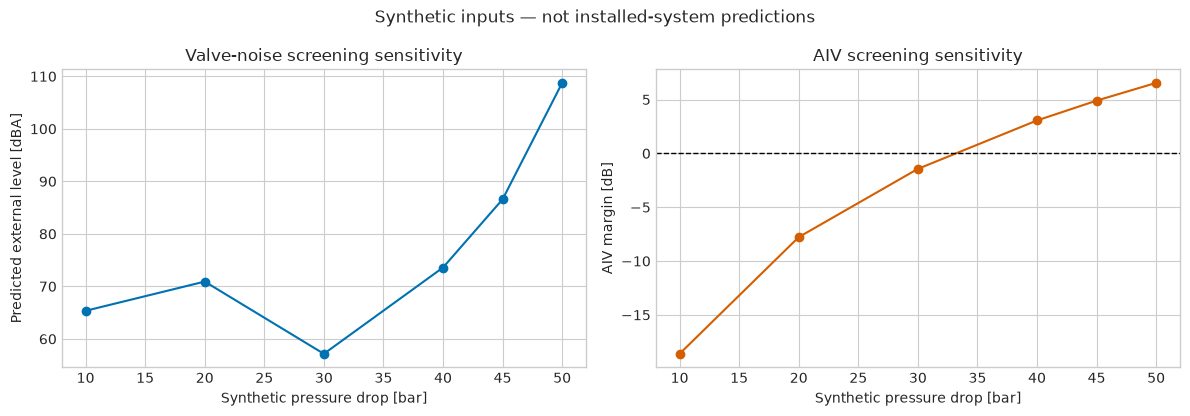

,outlet pressure [bara abs],pressure drop [bar],downstream temperature [K],external level [dBA],flow regime [-],AIV margin [dB],AIV likelihood
0,45,10,314.11,65.348,1,-18.616,LOW
1,35,20,309.8,70.915,1,-7.7792,MEDIUM
2,25,30,305.23,57.159,2,-1.4399,MEDIUM
3,15,40,300.38,73.588,2,3.0579,HIGH
4,10,45,297.86,86.583,2,4.8994,HIGH
5,5,50,295.27,108.75,2,6.5466,HIGH


In [7]:
def downstream_state_at_pressure(outlet_pressure_bara):
    fluid_state = upstream_fluid.clone()
    fluid_state.setPressure(outlet_pressure_bara, "bara")
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
        fluid_state
    )
    operations.PHflash(upstream_fluid.getEnthalpy())
    fluid_state.initProperties()
    fluid_state.initPhysicalProperties()
    return fluid_state


def screen_pressure_case(outlet_pressure_bara):
    fluid_state = downstream_state_at_pressure(outlet_pressure_bara)
    phase = fluid_state.getPhase(0)
    density = phase.getDensity("kg/m3")
    sound_speed = phase.getSoundSpeed()
    kappa = phase.getCp("J/kgK") / phase.getCv("J/kgK")

    noise_case = ValveNoise()
    noise_case.setFlowConditions(
        MASS_FLOW_KG_PER_S,
        UPSTREAM_PRESSURE_BARA * 1.0e5,
        outlet_pressure_bara * 1.0e5,
        upstream_density_kg_per_m3,
        density,
    )
    noise_case.setAcousticProperties(
        upstream_sound_speed_m_per_s,
        sound_speed,
        kappa,
    )
    noise_case.setGeometry(
        VALVE_OUTLET_DIAMETER_M,
        PIPE_INTERNAL_DIAMETER_M,
        PIPE_WALL_THICKNESS_M,
    )
    noise_case.setValveCoefficients(
        VALVE_PRESSURE_RECOVERY_FACTOR,
        VALVE_STYLE_MODIFIER,
    )
    noise_case.calcNoise()

    aiv_case = AivScreen.screen(
        "Synthetic pressure sensitivity",
        MASS_FLOW_KG_PER_S,
        UPSTREAM_PRESSURE_BARA,
        outlet_pressure_bara,
        TEMPERATURE_K,
        molecular_weight_g_per_mol,
        PIPE_OUTSIDE_DIAMETER_M,
        PIPE_WALL_THICKNESS_M,
    )

    return {
        "outlet pressure [bara abs]": outlet_pressure_bara,
        "pressure drop [bar]": UPSTREAM_PRESSURE_BARA - outlet_pressure_bara,
        "downstream temperature [K]": fluid_state.getTemperature("K"),
        "external level [dBA]": noise_case.getSoundPressureLevelDbA(),
        "flow regime [-]": noise_case.getFlowRegime(),
        "AIV margin [dB]": aiv_case.getMarginDb(),
        "AIV likelihood": str(aiv_case.getLikelihood()),
    }


outlet_pressures_bara = np.array([45.0, 35.0, 25.0, 15.0, 10.0, 5.0])
pressure_sensitivity = pd.DataFrame(
    [screen_pressure_case(value) for value in outlet_pressures_bara]
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(
    pressure_sensitivity["pressure drop [bar]"],
    pressure_sensitivity["external level [dBA]"],
    marker="o",
    color="#0072B2",
)
axes[0].set_xlabel("Synthetic pressure drop [bar]")
axes[0].set_ylabel("Predicted external level [dBA]")
axes[0].set_title("Valve-noise screening sensitivity")

axes[1].plot(
    pressure_sensitivity["pressure drop [bar]"],
    pressure_sensitivity["AIV margin [dB]"],
    marker="o",
    color="#D55E00",
)
axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_xlabel("Synthetic pressure drop [bar]")
axes[1].set_ylabel("AIV margin [dB]")
axes[1].set_title("AIV screening sensitivity")

figure.suptitle("Synthetic inputs — not installed-system predictions", fontsize=12)
figure.tight_layout()
plt.show()

pressure_sensitivity

## 5. Why the generated steady RANS case cannot find the tone

For the synthetic downstream state, the mean hydraulic quantities below can be transferred to
a steady RANS model. That model may answer where mean recirculation, velocity, or wall shear
is high. It has no resolved physical time axis, so it cannot produce a 500–1000 Hz spectrum,
phase, coherence, or acoustic propagation.

| Question | Steady RANS | Required causal method |
|---|---:|---|
| Mean pressure loss | Suitable after mesh and model qualification | RANS or validated correlation |
| Mean velocity and wall shear hot spots | Suitable with actual geometry | RANS with wall and mesh checks |
| Narrow-band source frequency | Not observable | Transient compressible URANS/LES/hybrid or validated CAA |
| Acoustic propagation | Not represented by incompressible steady flow | Compressible transient field plus acoustic method |
| Structural resonance | Outside the fluid-only model | As-built FE/modal test or operational deflection shapes |
| Installed root cause | Cannot declare | Synchronized multi-domain evidence and intervention |

The acoustic wavelength is

$$\lambda=\frac{c}{f}$$

Even if a mesh resolves the acoustic wavelength, it must also resolve the real valve passages,
separation regions, shear layers, and boundary conditions that generate the unsteady loading.

In [8]:
FREQUENCY_BAND_HZ = (500.0, 1_000.0)
POINTS_PER_PERIOD = 40
ACOUSTIC_POINTS_PER_WAVELENGTH = 12
SYNTHETIC_MINIMUM_CELL_M = 0.001
TARGET_COURANT_NUMBER = 0.8

wavelength_at_500_hz_m = (
    downstream_sound_speed_m_per_s / FREQUENCY_BAND_HZ[0]
)
wavelength_at_1000_hz_m = (
    downstream_sound_speed_m_per_s / FREQUENCY_BAND_HZ[1]
)
spectral_time_step_s = 1.0 / (
    POINTS_PER_PERIOD * FREQUENCY_BAND_HZ[1]
)
courant_time_step_s = (
    TARGET_COURANT_NUMBER
    * SYNTHETIC_MINIMUM_CELL_M
    / (downstream_sound_speed_m_per_s + bulk_velocity_m_per_s)
)
controlling_time_step_s = min(spectral_time_step_s, courant_time_step_s)
acoustic_cell_size_m = (
    wavelength_at_1000_hz_m / ACOUSTIC_POINTS_PER_WAVELENGTH
)

resolution_requirements = pd.Series(
    {
        "wavelength at 500 Hz [m]": wavelength_at_500_hz_m,
        "wavelength at 1000 Hz [m]": wavelength_at_1000_hz_m,
        "12-point acoustic cell at 1000 Hz [m]": acoustic_cell_size_m,
        "40-point spectral time step [microsecond]": (
            1.0e6 * spectral_time_step_s
        ),
        "synthetic 1 mm CFL time step [microsecond]": (
            1.0e6 * courant_time_step_s
        ),
        "controlling illustrative time step [microsecond]": (
            1.0e6 * controlling_time_step_s
        ),
    },
    name="Illustrative transient-resolution targets",
)

resolution_requirements

wavelength at 500 Hz [m]                            0.82899
wavelength at 1000 Hz [m]                           0.41449
12-point acoustic cell at 1000 Hz [m]              0.034541
40-point spectral time step [microsecond]                25
synthetic 1 mm CFL time step [microsecond]           1.7462
controlling illustrative time step [microsecond]     1.7462
Name: Illustrative transient-resolution targets, dtype: float64

## 6. Run a transient compressible CFD/CAA verification

This cell runs a real time-marching finite-volume calculation of the one-dimensional
linearized compressible Euler equations. The NeqSim downstream density and speed of sound are
used as the mean state. A localized 750 Hz pressure source is deliberately imposed so that
the numerical path can be checked against a known answer:

$$\frac{\partial p'}{\partial t}+c^2\frac{\partial m'}{\partial x}=S_p$$

$$\frac{\partial m'}{\partial t}+\frac{\partial p'}{\partial x}=0$$

where $m'=\rho_0u'$. A Rusanov interface flux, an explicit Courant number below one, and
end-zone damping are used. Virtual pressure sensors must recover the forcing frequency.

This is a **solver and sampling verification**, not a model of the installed valve. It has no
valve internals, turbulence-generated source, three-dimensional shear layer, real wall
impedance, or as-built piping. Passing it proves that the notebook actually resolves an
unsteady compressible pressure field and spectrum; it does not satisfy the causal CFD gate
for the real case.

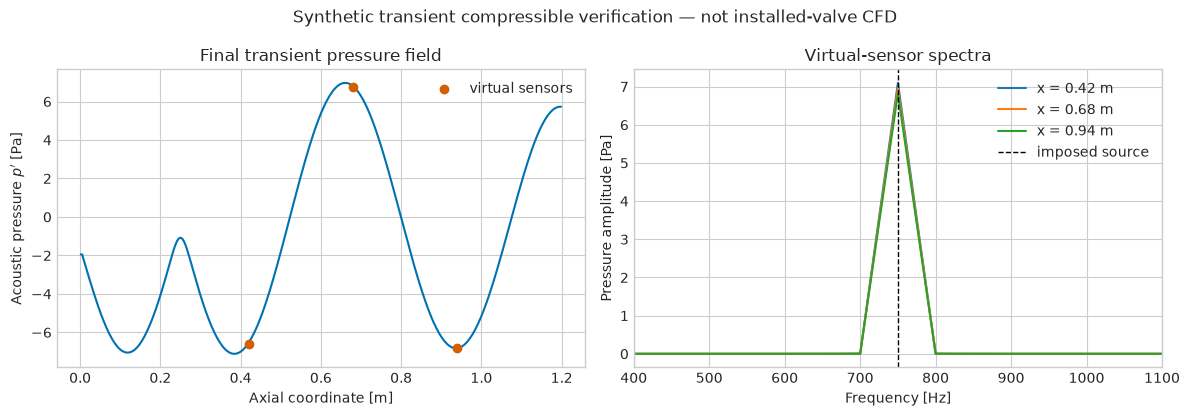

method                        1D linearized compressible Euler, finite volume
cells                                                                     360
time steps                                                              11479
time step [microsecond]                                                5.2269
Courant number                                                        0.64996
imposed source [Hz]                                                       750
recovered sensor peak [Hz]                                             750.07
real installed geometry                                                 False
causal CFD gate satisfied                                               False
Name: Transient compressible CFD/CAA verification, dtype: object

In [9]:
CFD_DOMAIN_LENGTH_M = 1.2
CFD_CELL_COUNT = 360
CFD_COURANT_NUMBER = 0.65
CFD_DURATION_S = 0.060
CFD_SOURCE_FREQUENCY_HZ = 750.0
CFD_SOURCE_LOCATION_M = 0.25
CFD_SOURCE_WIDTH_M = 0.012
CFD_SOURCE_RATE_PA_PER_S = 2.0e5

cfd_x_m = (
    np.arange(CFD_CELL_COUNT) + 0.5
) * CFD_DOMAIN_LENGTH_M / CFD_CELL_COUNT
cfd_dx_m = CFD_DOMAIN_LENGTH_M / CFD_CELL_COUNT
cfd_dt_s = CFD_COURANT_NUMBER * cfd_dx_m / downstream_sound_speed_m_per_s
cfd_step_count = math.ceil(CFD_DURATION_S / cfd_dt_s)
cfd_dt_s = CFD_DURATION_S / cfd_step_count
cfd_actual_courant = downstream_sound_speed_m_per_s * cfd_dt_s / cfd_dx_m

# q[0] is acoustic pressure p' [Pa]; q[1] is mass-flux perturbation m' [kg/(m2 s)].
acoustic_state = np.zeros((2, CFD_CELL_COUNT), dtype=float)
source_shape = np.exp(
    -0.5 * ((cfd_x_m - CFD_SOURCE_LOCATION_M) / CFD_SOURCE_WIDTH_M) ** 2
)

edge_fraction = 0.16
edge_distance = np.minimum(cfd_x_m, CFD_DOMAIN_LENGTH_M - cfd_x_m)
sponge_coordinate = np.clip(
    (edge_fraction * CFD_DOMAIN_LENGTH_M - edge_distance)
    / (edge_fraction * CFD_DOMAIN_LENGTH_M),
    0.0,
    1.0,
)
sponge_rate_per_s = 900.0 * sponge_coordinate**2
sponge_decay = np.exp(-sponge_rate_per_s * cfd_dt_s)

sensor_locations_m = np.array([0.42, 0.68, 0.94])
sensor_indices = np.array(
    [np.argmin(np.abs(cfd_x_m - location)) for location in sensor_locations_m]
)
sensor_pressure_pa = np.zeros((sensor_indices.size, cfd_step_count))
cfd_time_s = np.arange(cfd_step_count) * cfd_dt_s

for step_index, current_time_s in enumerate(cfd_time_s):
    physical_flux = np.vstack(
        (
            downstream_sound_speed_m_per_s**2 * acoustic_state[1],
            acoustic_state[0],
        )
    )
    interface_flux = 0.5 * (
        physical_flux[:, :-1] + physical_flux[:, 1:]
    ) - 0.5 * downstream_sound_speed_m_per_s * (
        acoustic_state[:, 1:] - acoustic_state[:, :-1]
    )

    updated_state = acoustic_state.copy()
    updated_state[:, 1:-1] -= cfd_dt_s / cfd_dx_m * (
        interface_flux[:, 1:] - interface_flux[:, :-1]
    )
    updated_state[:, 0] = updated_state[:, 1]
    updated_state[:, -1] = updated_state[:, -2]
    updated_state[0] += (
        cfd_dt_s
        * CFD_SOURCE_RATE_PA_PER_S
        * np.sin(2.0 * np.pi * CFD_SOURCE_FREQUENCY_HZ * current_time_s)
        * source_shape
    )
    acoustic_state = updated_state * sponge_decay
    sensor_pressure_pa[:, step_index] = acoustic_state[0, sensor_indices]

analysis_start_index = np.searchsorted(cfd_time_s, 0.020)
cfd_analysis_time_s = cfd_time_s[analysis_start_index:]
cfd_frequency_hz = np.fft.rfftfreq(
    cfd_analysis_time_s.size,
    d=cfd_dt_s,
)
cfd_window = np.hanning(cfd_analysis_time_s.size)
cfd_spectrum_pa = np.abs(
    np.fft.rfft(
        sensor_pressure_pa[:, analysis_start_index:] * cfd_window,
        axis=1,
    )
)
cfd_spectrum_pa *= 2.0 / np.sum(cfd_window)

cfd_search_mask = (
    (cfd_frequency_hz >= FREQUENCY_BAND_HZ[0])
    & (cfd_frequency_hz <= FREQUENCY_BAND_HZ[1])
)
cfd_peak_frequency_hz = cfd_frequency_hz[cfd_search_mask][
    np.argmax(cfd_spectrum_pa[1, cfd_search_mask])
]
acoustic_energy_density_j_per_m3 = (
    acoustic_state[0] ** 2
    / (
        2.0
        * downstream_density_kg_per_m3
        * downstream_sound_speed_m_per_s**2
    )
    + acoustic_state[1] ** 2
    / (2.0 * downstream_density_kg_per_m3)
)

assert cfd_actual_courant < 1.0
assert np.all(np.isfinite(acoustic_state))
assert np.all(acoustic_energy_density_j_per_m3 >= 0.0)
assert abs(cfd_peak_frequency_hz - CFD_SOURCE_FREQUENCY_HZ) <= 30.0

cfd_verification = pd.Series(
    {
        "method": "1D linearized compressible Euler, finite volume",
        "cells": CFD_CELL_COUNT,
        "time steps": cfd_step_count,
        "time step [microsecond]": 1.0e6 * cfd_dt_s,
        "Courant number": cfd_actual_courant,
        "imposed source [Hz]": CFD_SOURCE_FREQUENCY_HZ,
        "recovered sensor peak [Hz]": cfd_peak_frequency_hz,
        "real installed geometry": False,
        "causal CFD gate satisfied": False,
    },
    name="Transient compressible CFD/CAA verification",
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(cfd_x_m, acoustic_state[0], color="#0072B2")
axes[0].scatter(
    sensor_locations_m,
    acoustic_state[0, sensor_indices],
    color="#D55E00",
    label="virtual sensors",
    zorder=3,
)
axes[0].set_xlabel("Axial coordinate [m]")
axes[0].set_ylabel("Acoustic pressure $p'$ [Pa]")
axes[0].set_title("Final transient pressure field")
axes[0].legend()

for sensor_index, sensor_location_m in enumerate(sensor_locations_m):
    axes[1].plot(
        cfd_frequency_hz,
        cfd_spectrum_pa[sensor_index],
        label=f"x = {sensor_location_m:.2f} m",
    )
axes[1].axvline(
    CFD_SOURCE_FREQUENCY_HZ,
    color="black",
    linewidth=1.0,
    linestyle="--",
    label="imposed source",
)
axes[1].set_xlim(400.0, 1_100.0)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Pressure amplitude [Pa]")
axes[1].set_title("Virtual-sensor spectra")
axes[1].legend()

figure.suptitle("Synthetic transient compressible verification — not installed-valve CFD")
figure.tight_layout()
plt.show()

cfd_verification

## 7. A synthetic spectrum shows the inference error

Two synthetic recordings contain the same 750 Hz tone. The second has lower amplitude after
an illustrative pressure reduction. This reproduces the logical structure of the observation
without claiming to reproduce field data.

With record length $T$ and sample rate $f_s$,

$$\Delta f=\frac{1}{T},\qquad f_{\mathrm{Nyquist}}=\frac{f_s}{2}$$

The amplitude change proves a response change. Because the synthetic microphones and
accelerometers have no spatial phase or coherence information, it still cannot locate the
source.

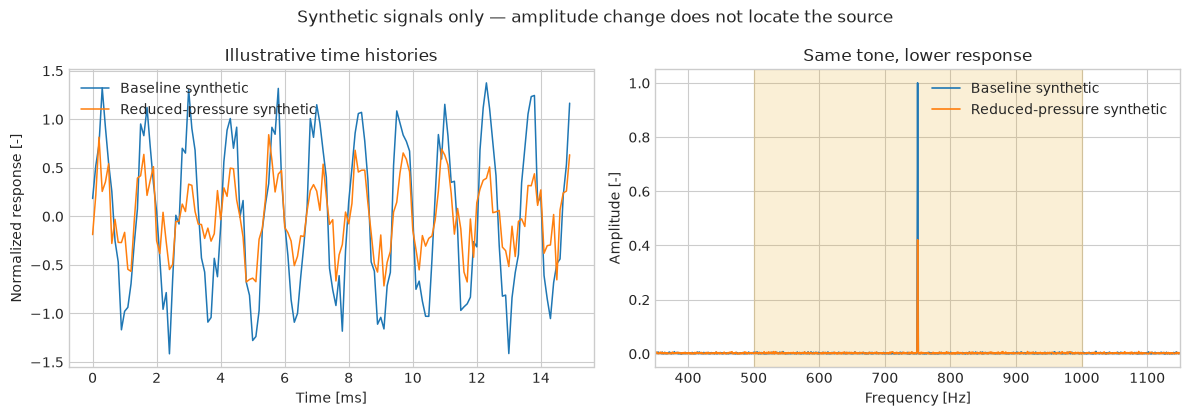

sample rate [Hz]             10,000
record length [s]                 2
frequency resolution [Hz]       0.5
Nyquist frequency [Hz]        5,000
baseline peak [Hz]              750
reduced-pressure peak [Hz]      750
Name: Synthetic spectral evidence, dtype: float64

In [10]:
SAMPLE_RATE_HZ = 10_000.0
RECORD_LENGTH_S = 2.0
SYNTHETIC_TONE_HZ = 750.0

time_s = np.arange(0.0, RECORD_LENGTH_S, 1.0 / SAMPLE_RATE_HZ)
random_generator = np.random.default_rng(20260824)

baseline_signal = (
    np.sin(2.0 * np.pi * SYNTHETIC_TONE_HZ * time_s)
    + 0.18 * random_generator.standard_normal(time_s.size)
)
reduced_pressure_signal = (
    0.42 * np.sin(2.0 * np.pi * SYNTHETIC_TONE_HZ * time_s)
    + 0.18 * random_generator.standard_normal(time_s.size)
)


def one_sided_power(signal, sample_rate_hz):
    window = np.hanning(signal.size)
    coherent_gain = np.sum(window) / signal.size
    spectrum = np.fft.rfft(signal * window)
    frequency_hz = np.fft.rfftfreq(signal.size, d=1.0 / sample_rate_hz)
    amplitude = 2.0 * np.abs(spectrum) / signal.size / coherent_gain
    return frequency_hz, amplitude


frequency_hz, baseline_amplitude = one_sided_power(
    baseline_signal,
    SAMPLE_RATE_HZ,
)
_, reduced_amplitude = one_sided_power(
    reduced_pressure_signal,
    SAMPLE_RATE_HZ,
)

search_mask = (
    (frequency_hz >= FREQUENCY_BAND_HZ[0])
    & (frequency_hz <= FREQUENCY_BAND_HZ[1])
)
baseline_peak_hz = frequency_hz[search_mask][
    np.argmax(baseline_amplitude[search_mask])
]
reduced_peak_hz = frequency_hz[search_mask][
    np.argmax(reduced_amplitude[search_mask])
]

figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
time_window = time_s <= 0.015
axes[0].plot(
    1_000.0 * time_s[time_window],
    baseline_signal[time_window],
    label="Baseline synthetic",
    linewidth=1.1,
)
axes[0].plot(
    1_000.0 * time_s[time_window],
    reduced_pressure_signal[time_window],
    label="Reduced-pressure synthetic",
    linewidth=1.1,
)
axes[0].set_xlabel("Time [ms]")
axes[0].set_ylabel("Normalized response [-]")
axes[0].set_title("Illustrative time histories")
axes[0].legend()

axes[1].plot(
    frequency_hz,
    baseline_amplitude,
    label="Baseline synthetic",
    linewidth=1.2,
)
axes[1].plot(
    frequency_hz,
    reduced_amplitude,
    label="Reduced-pressure synthetic",
    linewidth=1.2,
)
axes[1].axvspan(500.0, 1_000.0, color="#E69F00", alpha=0.16)
axes[1].set_xlim(350.0, 1_150.0)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Amplitude [-]")
axes[1].set_title("Same tone, lower response")
axes[1].legend()

figure.suptitle("Synthetic signals only — amplitude change does not locate the source")
figure.tight_layout()
plt.show()

spectral_summary = pd.Series(
    {
        "sample rate [Hz]": SAMPLE_RATE_HZ,
        "record length [s]": RECORD_LENGTH_S,
        "frequency resolution [Hz]": 1.0 / RECORD_LENGTH_S,
        "Nyquist frequency [Hz]": SAMPLE_RATE_HZ / 2.0,
        "baseline peak [Hz]": baseline_peak_hz,
        "reduced-pressure peak [Hz]": reduced_peak_hz,
    },
    name="Synthetic spectral evidence",
)

spectral_summary

## 8. Side-branch and check-device resonance: geometry is the test

For a closed acoustic branch, the idealized quarter-wave modes are

$$f_n=\frac{(2n+1)c}{4L}$$

For an open termination, the idealized half-wave modes are

$$f_n=\frac{(n+1)c}{2L}$$

The Strouhal shedding estimate uses an effective branch-mouth width $W$:

$$f_s=\mathrm{St}\frac{U}{W}$$

The NeqSim pulsation screen compares those quantities within a lock-in envelope. A sweep is
useful here because it proves non-uniqueness: many plausible lengths can place a mode inside
500–1000 Hz. Only the actual as-built acoustic length, diameter, edge radius, termination, gas
state, and measured velocity can test this hypothesis.

Synthetic shedding frequency: 205.61 Hz
Any synthetic mode locked in: True


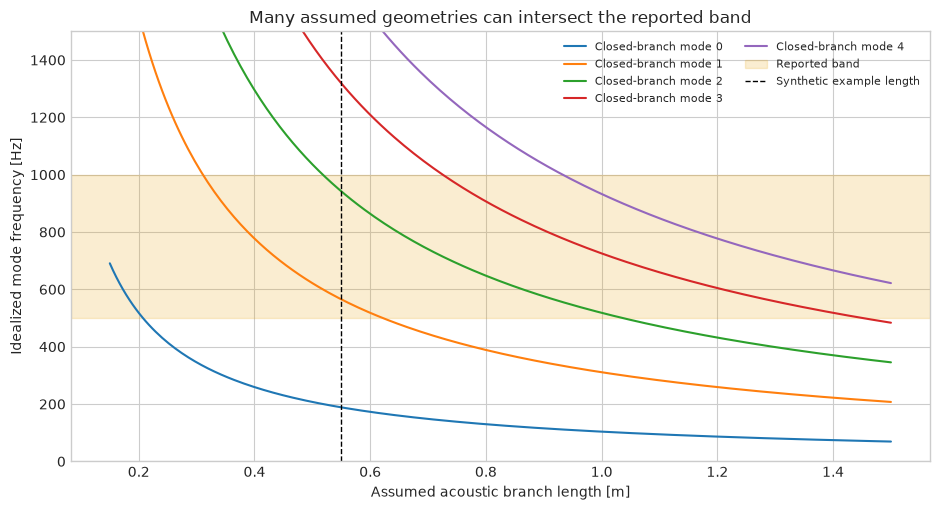

,mode,frequency [Hz],lock-in low [Hz],lock-in high [Hz],locked in
0,0,188.41,150.73,226.09,True
1,1,565.22,452.18,678.26,False
2,2,942.03,753.63,"1,130.4",False
3,3,"1,318.8","1,055.1","1,582.6",False
4,4,"1,695.7","1,356.5","2,034.8",False


In [11]:
PulsationScreen = (
    jneqsim.process.safety.vibration.FlowInducedPulsationScreening
)
ClosedTermination = PulsationScreen.AcousticTermination.CLOSED

SYNTHETIC_BRANCH_LENGTH_M = 0.55
SYNTHETIC_BRANCH_DIAMETER_M = 0.10

pulsation_result = PulsationScreen.screen(
    "Synthetic side branch",
    SYNTHETIC_BRANCH_LENGTH_M,
    SYNTHETIC_BRANCH_DIAMETER_M,
    PIPE_INTERNAL_DIAMETER_M,
    bulk_velocity_m_per_s,
    downstream_density_kg_per_m3,
    downstream_sound_speed_m_per_s,
)

mode_table = pd.DataFrame(
    [
        {
            "mode": int(mode.getModeIndex()),
            "frequency [Hz]": mode.getFrequencyHz(),
            "lock-in low [Hz]": mode.getEnvelopeLowHz(),
            "lock-in high [Hz]": mode.getEnvelopeHighHz(),
            "locked in": bool(mode.isLockedIn()),
        }
        for mode in pulsation_result.getModes()
    ]
)

branch_lengths_m = np.linspace(0.15, 1.50, 240)
figure, axis = plt.subplots(figsize=(9.5, 5.2))

for mode_index in range(5):
    mode_frequencies_hz = [
        PulsationScreen.eigenFrequency(
            mode_index,
            downstream_sound_speed_m_per_s,
            branch_length_m,
            ClosedTermination,
        )
        for branch_length_m in branch_lengths_m
    ]
    axis.plot(
        branch_lengths_m,
        mode_frequencies_hz,
        label=f"Closed-branch mode {mode_index}",
    )

axis.axhspan(500.0, 1_000.0, color="#E69F00", alpha=0.18, label="Reported band")
axis.axvline(
    SYNTHETIC_BRANCH_LENGTH_M,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Synthetic example length",
)
axis.set_ylim(0.0, 1_500.0)
axis.set_xlabel("Assumed acoustic branch length [m]")
axis.set_ylabel("Idealized mode frequency [Hz]")
axis.set_title("Many assumed geometries can intersect the reported band")
axis.legend(ncol=2, fontsize=8)
figure.tight_layout()
plt.show()

print(
    "Synthetic shedding frequency:",
    f"{pulsation_result.getSheddingFrequencyHz():.2f} Hz",
)
print("Any synthetic mode locked in:", bool(pulsation_result.isAnyModeLockedIn()))
mode_table

## 9. Required measurement and simulation package

To discriminate the competing mechanisms, collect one synchronized package across stable
operating points and controlled transitions:

| Evidence | Minimum content | Discriminates |
|---|---|---|
| Process trends | $P_1$, $P_2$, $T$, mass flow, valve position/$C_v$, machine speed/load | Pressure-drop, Strouhal, and order scaling |
| Acoustic measurements | Calibrated time histories at multiple locations, sample rate, anti-alias filter | Tone, spatial decay, phase, and coherence |
| Vibration measurements | Tri-axial pipe/valve/support and machine channels with shared clock | Structural mode, support response, machine order |
| Valve geometry | Body, trim, shaft/disc/cage, openings, clearances, adjacent reducers | Real CFD source geometry and IEC coefficients |
| Piping geometry | Run/branch IDs, lengths, edge radii, termination, wall thickness, supports | Acoustic modes, AIV, FIV, and FE modes |
| Structural dynamics | As-built mass/stiffness/support model, modal test or ODS, damping | Natural frequency, mode shape, response path |
| Transient CFD/CAA | Compressible time-accurate field, validated mesh/time step, spectra | Candidate aerodynamic source and propagation |
| Intervention | Repeatable change with before/after synchronized evidence | Causal challenge and falsification |

For the 1 kHz upper band edge, a practical measurement rate should comfortably exceed the
Nyquist minimum and retain anti-alias margin. A 10 kHz or higher rate is a defensible starting
point for this narrow band, while the actual sensor chain and higher harmonics may require more.

In [12]:
measurement_requirements = pd.DataFrame(
    [
        {
            "quantity": "Sample rate",
            "screening target": ">= 10 kHz",
            "reason": "At least 10 samples/cycle at 1 kHz plus anti-alias margin",
        },
        {
            "quantity": "Record length",
            "screening target": ">= 2 s per stable point",
            "reason": "0.5 Hz bin spacing before averaging",
        },
        {
            "quantity": "Operating points",
            "screening target": ">= 4 stable states",
            "reason": "Test fixed-frequency, order, and Strouhal scaling",
        },
        {
            "quantity": "Spatial channels",
            "screening target": ">= 2 acoustic and >= 3 vibration",
            "reason": "Estimate coherence, phase, decay, and response path",
        },
        {
            "quantity": "Clock",
            "screening target": "Shared or demonstrably synchronized",
            "reason": "Required for transfer functions and phase evidence",
        },
    ]
)

measurement_requirements

,quantity,screening target,reason
0,Sample rate,>= 10 kHz,At least 10 samples/cycle at 1 kHz plus anti-alias margin
1,Record length,>= 2 s per stable point,0.5 Hz bin spacing before averaging
2,Operating points,>= 4 stable states,"Test fixed-frequency, order, and Strouhal scaling"
3,Spatial channels,>= 2 acoustic and >= 3 vibration,"Estimate coherence, phase, decay, and response path"
4,Clock,Shared or demonstrably synchronized,Required for transfer functions and phase evidence


## 10. Agent and skill routing contract

The router below makes the causal boundary executable. It treats the steady RANS result as a
hydraulic input only. A reported tone automatically activates transient compressible
aeroacoustics and structural/modal work. Missing real geometry or synchronized data blocks a
causal declaration rather than triggering a confident narrative.

In [13]:
case_state = {
    "reported_tone": True,
    "mean_hydraulic_state": True,
    "steady_rans_case": True,
    "synchronized_spectra": False,
    "operating_state_trends": False,
    "actual_valve_geometry": False,
    "actual_branch_geometry": False,
    "synthetic_transient_cfd_demo": True,
    "transient_compressible_cfd": False,
    "structural_modal_data": False,
    "mesh_time_independence": False,
    "multi_source_corroboration": False,
    "repeatable_intervention": False,
}


def route_tonal_case(state):
    rows = []
    rows.append(
        {
            "route": "NeqSim thermodynamic and pressure-drop state",
            "status": "READY" if state["mean_hydraulic_state"] else "BLOCKED",
            "allowed conclusion": "Boundary conditions and screening energy",
        }
    )
    rows.append(
        {
            "route": "Steady RANS local hydraulics",
            "status": "LIMITED" if state["steady_rans_case"] else "NOT RUN",
            "allowed conclusion": "Mean velocity, pressure, and wall shear only",
        }
    )
    transient_ready = all(
        [
            state["actual_valve_geometry"],
            state["operating_state_trends"],
            state["synchronized_spectra"],
        ]
    )
    rows.append(
        {
            "route": "Transient compressible aeroacoustics",
            "status": (
                "READY"
                if transient_ready
                else "BLOCKED — SYNTHETIC VERIFICATION ONLY"
            ),
            "allowed conclusion": "Unsteady source candidate and acoustic field",
        }
    )
    branch_ready = all(
        [
            state["actual_branch_geometry"],
            state["operating_state_trends"],
            state["synchronized_spectra"],
        ]
    )
    rows.append(
        {
            "route": "Side-branch or check-device pulsation",
            "status": "READY" if branch_ready else "BLOCKED",
            "allowed conclusion": "Mode and Strouhal lock-in test",
        }
    )
    structural_ready = all(
        [
            state["structural_modal_data"],
            state["synchronized_spectra"],
        ]
    )
    rows.append(
        {
            "route": "Structural modal and response analysis",
            "status": "READY" if structural_ready else "BLOCKED",
            "allowed conclusion": "Mode shape, damping, and response path",
        }
    )

    causal_requirements = [
        "synchronized_spectra",
        "operating_state_trends",
        "actual_valve_geometry",
        "actual_branch_geometry",
        "transient_compressible_cfd",
        "structural_modal_data",
        "mesh_time_independence",
        "multi_source_corroboration",
        "repeatable_intervention",
    ]
    missing = [name for name in causal_requirements if not state[name]]
    verdict = "CAUSE MAY BE EVALUATED" if not missing else "STOP — CAUSE UNRESOLVED"
    return pd.DataFrame(rows), verdict, missing


routing_table, causal_verdict, missing_causal_evidence = route_tonal_case(case_state)

print(causal_verdict)
print("Missing causal evidence:")
for missing_item in missing_causal_evidence:
    print("-", missing_item.replace("_", " "))

routing_table

STOP — CAUSE UNRESOLVED
Missing causal evidence:
- synchronized spectra
- operating state trends
- actual valve geometry
- actual branch geometry
- transient compressible cfd
- structural modal data
- mesh time independence
- multi source corroboration
- repeatable intervention


,route,status,allowed conclusion
0,NeqSim thermodynamic and pressure-drop state,READY,Boundary conditions and screening energy
1,Steady RANS local hydraulics,LIMITED,"Mean velocity, pressure, and wall shear only"
2,Transient compressible aeroacoustics,BLOCKED — SYNTHETIC VERIFICATION ONLY,Unsteady source candidate and acoustic field
3,Side-branch or check-device pulsation,BLOCKED,Mode and Strouhal lock-in test
4,Structural modal and response analysis,BLOCKED,"Mode shape, damping, and response path"


## 11. Multi-hypothesis evidence synthesis

NeqSim's `EvidenceSynthesis` ranks hypotheses while preserving source types and a
single-source warning. The two available case statements are entered at moderate or low
strength. Missing evidence is not converted to supporting evidence.

The ranking is triage. The top row is **not** a root-cause conclusion.

In [14]:
EvidenceSynthesis = jneqsim.util.agentic.EvidenceSynthesis
evidence_model = EvidenceSynthesis()

hypotheses = {
    "H1": "Valve-generated aerodynamic source",
    "H2": "Side-branch or check-device acoustic lock-in",
    "H3": "Structural or support resonance",
    "H4": "Machine-order excitation",
    "H5": "Main-line flow-induced vibration",
}

for hypothesis_id, description in hypotheses.items():
    evidence_model.addHypothesis(hypothesis_id, description)

evidence_model.addEvidence(
    "H1",
    "field-intervention-note",
    True,
    0.55,
    "Response decreased after pressure reduction; source location is not established.",
)
evidence_model.addEvidence(
    "H2",
    "field-tone-note",
    True,
    0.35,
    "A narrow-band tone was reported; spectrum and geometry are unavailable.",
)

evidence_json = json.loads(str(evidence_model.toJson()))
ranked_hypotheses = pd.DataFrame(evidence_json["hypotheses"])[
    [
        "rank",
        "id",
        "description",
        "netScore",
        "supportingSourceCount",
        "corroborated",
        "confidence",
    ]
]

assert evidence_json["singleSourceWarning"] is True
assert ranked_hypotheses.iloc[0]["confidence"] == "WEAK"

print("Top hypothesis:", evidence_json["topHypothesisId"])
print("Single-source warning:", evidence_json["singleSourceWarning"])
ranked_hypotheses

Top hypothesis: H1
Single-source warning: True


,rank,id,description,netScore,supportingSourceCount,corroborated,confidence
0,1,H1,Valve-generated aerodynamic source,0.55,1,False,WEAK
1,2,H2,Side-branch or check-device acoustic lock-in,0.35,1,False,WEAK
2,3,H3,Structural or support resonance,0,0,False,UNSUPPORTED
3,4,H4,Machine-order excitation,0,0,False,UNSUPPORTED
4,5,H5,Main-line flow-induced vibration,0,0,False,UNSUPPORTED


## 12. PEPR decision gate

A cause may be declared only when the following evidence chain is complete:

$$\text{source signature}\rightarrow\text{propagation path}\rightarrow\text{structural response}\rightarrow\text{repeatable intervention}$$

The chain must be tied to the same clock and operating state. A matching frequency without
phase/coherence, a calculated screen without actual geometry, or a response reduction without
source localization leaves the cause unresolved.

In [15]:
pepr_gate = pd.DataFrame(
    [
        {
            "gate": "Thermodynamic boundary and pressure-drop energy",
            "status": "PASS FOR SYNTHETIC SCREEN",
            "evidence": "NeqSim SRK and screening calculations executed",
        },
        {
            "gate": "Actual valve and piping geometry",
            "status": "BLOCKED",
            "evidence": "Not present in the public case",
        },
        {
            "gate": "Synchronized spectra and operating-state trends",
            "status": "BLOCKED",
            "evidence": "Only qualitative statements are available",
        },
        {
            "gate": "Transient compressible aeroacoustic model",
            "status": "BLOCKED",
            "evidence": "Steady RANS is not admissible for tonal source identification",
        },
        {
            "gate": "Structural modal and response-path evidence",
            "status": "BLOCKED",
            "evidence": "Natural frequencies, damping, and mode shapes are missing",
        },
        {
            "gate": "Independent corroboration and intervention",
            "status": "BLOCKED",
            "evidence": "Top hypothesis has one supporting source type",
        },
        {
            "gate": "Root-cause declaration",
            "status": causal_verdict,
            "evidence": "Mandatory causal inputs remain missing",
        },
    ]
)

assert causal_verdict == "STOP — CAUSE UNRESOLVED"
pepr_gate

,gate,status,evidence
0,Thermodynamic boundary and pressure-drop energy,PASS FOR SYNTHETIC SCREEN,NeqSim SRK and screening calculations executed
1,Actual valve and piping geometry,BLOCKED,Not present in the public case
2,Synchronized spectra and operating-state trends,BLOCKED,Only qualitative statements are available
3,Transient compressible aeroacoustic model,BLOCKED,Steady RANS is not admissible for tonal source identification
4,Structural modal and response-path evidence,BLOCKED,"Natural frequencies, damping, and mode shapes are missing"
5,Independent corroboration and intervention,BLOCKED,Top hypothesis has one supporting source type
6,Root-cause declaration,STOP — CAUSE UNRESOLVED,Mandatory causal inputs remain missing


## 13. PEPR conclusion and next action

**Conclusion:** the pressure-reduction response supports the statement that acoustic or
vibratory energy changes with operating conditions. It does not establish that the
pressure-reducing valve is the source. The valve, a side branch or check device, a structural
or support mode, machine excitation, and main-line FIV remain competing hypotheses.

**The existing steady RANS case remains useful** for mean local velocity, recirculation, wall
shear, and pressure loss after geometry and mesh qualification. It is explicitly rejected as
evidence for a 500–1000 Hz tonal source because it has no resolved unsteady compressible
pressure field.

**Next evidence package:**

1. obtain actual valve internals and adjacent run/branch/support geometry;
2. acquire synchronized pressure, flow, valve position, machine speed/load, acoustic, and
   tri-axial vibration time histories over at least four stable states and one controlled change;
3. test fixed-frequency, machine-order, and Strouhal scaling plus spatial phase/coherence;
4. obtain as-built modal frequencies, damping, and mode shapes or operational deflection shapes;
5. run mesh- and time-step-qualified transient compressible aeroacoustics on the actual geometry;
6. repeat a safe intervention and require the model and measurements to predict the same change;
7. re-run the evidence synthesis and declare a cause only when at least two independent source
   types corroborate the full source–path–response chain.

### Validation statement

- The thermodynamic, valve-noise, AIV, pulsation, transient finite-volume CFD/CAA, spectral,
  and routing cells are executable from top to bottom in a clean runtime.
- All public numerical inputs are synthetic and non-identifying.
- Evidence level: thermodynamic consistency, dimensionless physical checks, Java regression
  patterns, analytical frequency relations, and defensible measurement bounds.
- This is an engineering investigation and teaching workflow, not design certification or a
  substitute for qualified acoustic, CFD, structural, and piping-integrity review.